# Machine Learning Algorithm2: Random Forest

<a id='Index'></a>
# Exercise list:
* <a href='#Exercise-01'>Exercise-01</a>
* <a href='#Exercise-02'>Exercise-02</a>
* <a href='#Exercise-03'>Exercise-03</a>

In [1]:
%spark 16 32g

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/01 16:40:10 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.4.2
      /_/

Using Python version 3.9.18 (main, Dec 15 2023 17:48:57)
Spark context Web UI available at None
Spark context available as 'sc' (master = local[*], app id = local-1759329611159).
SparkSession available as 'spark'.


In [2]:
%run handlers.ipynb

Pandas version:  2.1.4


# Read-in Manipulation DataFrames (similar to NB3)

* Read in the DataFrames **produced in the DataManipulation** Notebook as .csv files.
* Pre-saved data are in the read-only directory **local_data_dir_ro**. Data you produced are in **local_data_dir**.
* Goal is to obtain the training and test DataFrames df_train_classification and df_test_classification.

In [3]:
df_names= ['df_train_classification'+suffix_s_w+'.csv',\
           'df_test_classification'+suffix_s_w+'.csv']
path_lustre = []
for filename in df_names:
    path_lustre.append(os.path.join(local_data_dir_ro, filename))

print("Reading in all DataFrames from manipulation in... ")
start_time = time.time()

df_train_classification = spark.read.option('header', True).option('inferSchema', True)\
    .csv(os.path.join(LustrePrefix,path_lustre[0])).cache()
df_test_classification = spark.read.option('header', True).option('inferSchema', True)\
    .csv(os.path.join(LustrePrefix,path_lustre[1])).cache()

print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
    np.remainder(time.time() - start_time, 60)))

Reading in all DataFrames from manipulation in... 


25/10/01 16:40:31 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


--- 0 min. 4.21 sec.---


In [4]:
# Have a look at the training DataFrame scheme:
df_train_classification.printSchema()
#print('Number of entries (rows) in df_train_classification:', df_train_classification.count())

root
 |-- MONAT: integer (nullable = true)
 |-- TAG: integer (nullable = true)
 |-- STUNDE_SOLL: integer (nullable = true)
 |-- MINUTE_RANGE: integer (nullable = true)
 |-- ZUGEREIGNIS_LINIE: integer (nullable = true)
 |-- SERVICE_START_ZEIT: integer (nullable = true)
 |-- ZUGEREIGNIS_ISTZEIT: integer (nullable = true)
 |-- ZUGEREIGNIS_TYP: integer (nullable = true)
 |-- ZUGEREIGNIS_SOLLZEIT: integer (nullable = true)
 |-- SERVICE_ID: long (nullable = true)
 |-- ZUGEREIGNIS_ZUGNUMMER: integer (nullable = true)
 |-- ZUGEREIGNIS_DS100: string (nullable = true)
 |-- MINUTE_SOLL: integer (nullable = true)
 |-- STUNDE_SER: integer (nullable = true)
 |-- MINUTE_SER: integer (nullable = true)
 |-- WOCHENTAG_SER: string (nullable = true)
 |-- WOCHENTAG_SOLL: string (nullable = true)
 |-- VERSPAETUNG: integer (nullable = true)
 |-- LAUFSZEIT: integer (nullable = true)
 |-- Datum: timestamp (nullable = true)
 |-- Mittelwerte_Temperatur: double (nullable = true)
 |-- Mittelwerte_Rel_Feuchte: doub

# Prediction of a delayed event with Random Forest

<a href='#Index'>Exercise Index</a>
<a id='Exercise-01'></a>

**EXERCISE 1**

* Select all the **test data of the S1 line** as follows:
1. First, split the DataFrame into a list of DF according to the line number ('ZUGEREIGNIS_LINIE'). The function dfSplit is used (defined in handlers).

In [5]:
print("Split the test DataFrame for the line S1 into arrays according to the stations in...")
start_time = time.time()
df_array, list_line_ = DataHandler.dfSplit(df_test_classification, 'ZUGEREIGNIS_LINIE')
print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
                                  np.remainder(time.time() - start_time, 60)))
print('Line numbers found in df_test_classification:')
print(list_line_)

Split the test DataFrame for the line S1 into arrays according to the stations in...


--- 0 min. 2.11 sec.---
Line numbers found in df_test_classification:
[1, 6, 3, 5, 4, 60, 11, 2]


2. Then, select the DataFrame in the list corresponding to the S-Bahn line 1 (S1).

In [7]:
df_test_S1 = df_array[list_line_.index(1)]

* Split further the S1 data into another list of DataFrames: **df_arr_test_ds**, **one DataFrame for each station**
* A list of station codes is also produced: **list_test_S1_ds**

In [8]:
df_arr_test_ds, list_test_S1_ds = DataHandler.dfSplit(df_test_S1, 'ZUGEREIGNIS_DS100')
print('S1 goes through', len(list_test_S1_ds), '(unordered) stations:')
print(list_test_S1_ds)

S1 goes through 27 (unordered) stations:
['TWER', 'TSRO', 'TWD', 'TSMI', 'TP', 'TGOL', 'TSU', 'TS  T', 'TKTO', 'TSV', 'TOES', 'TE', 'TSUN', 'TSFS', 'TSOS', 'TACH', 'TSC', 'TEZL', 'TSNS', 'TEME', 'TSS', 'TSOM', 'THUB', 'TGT', 'TEHN', 'TBO', 'TNUF']


* Repeat the procedure above for the **training dataset**:

In [10]:
print("Split the training DataFrame for the line S1 into arrays according to the stations in...")
start_time = time.time()
df_array, list_line_ = DataHandler.dfSplit(df_train_classification, 'ZUGEREIGNIS_LINIE')
print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
                                  np.remainder(time.time() - start_time, 60)))

df_train_S1 = df_array[list_line_.index(1)]
    
# Then, split df_train_S1 (all events of S1) according to the stations.
# A list of DataFrames (df_arr_ds) and a list of S1 stations are created.
df_arr_train_ds, list_train_S1_ds = DataHandler.dfSplit(df_train_S1, 'ZUGEREIGNIS_DS100')

Split the training DataFrame for the line S1 into arrays according to the stations in...
--- 0 min. 0.72 sec.---


## Combinations of features (similar to NB3)
* The lists "columns to index" (col_to_inx) and "columns index" (col_inx) contain the same features (respectively without or with the "_index" suffix) for the function StringIndexer.
* **A different order of the two lists** does **not** have an impact on the LR algorithm.


* These feature combinations are ordered **from best to worst** prediction result (columns_index5, 4, 3, 2, 1), according to previous tests.

In [11]:
# Delay classification at station -1,-2 + Duration and additional features + Weather:
col_to_inx5 = [ 'ZUGEREIGNIS_DS100',  'STUNDE_SOLL',\
                    'LAUFSZEIT', 'prev0_classification', 'prev1_prev0_classification', 'Mittel_NO', 'Mittel_WG', 'ZUGEREIGNIS_TYP']
col_inx5 = [ 'prev0_classification_INDEX','prev1_prev0_classification_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'ZUGEREIGNIS_TYP_INDEX', \
                 'STUNDE_SOLL_INDEX', 'LAUFSZEIT_INDEX','Mittel_WG_INDEX', 'Mittel_NO_INDEX']

# Only delay classification at station -1,-2:
col_to_inx4 = ['prev0_classification', 'prev1_prev0_classification']
col_inx4 = ['prev0_classification_INDEX', 'prev1_prev0_classification_INDEX']

# Only delay classification at station -1:
col_to_inx3 = ['prev0_classification']
col_inx3 = ['prev0_classification_INDEX']

# Basic information of the original dataset (without additional features) + Weather information:
col_to_inx2 = ['ZUGEREIGNIS_ZUGNUMMER', 'ZUGEREIGNIS_DS100', 'SERVICE_START_ZEIT', \
                  'Mittelwerte_Temperatur', 'Mittel_WG', 'ZUGEREIGNIS_SOLLZEIT',\
                    'Summe_Niederschalg', 'Mittel_NO', 'Mittel_NO2', 'Mittel_O3', 'Mittel_PM10']
col_inx2 = ['ZUGEREIGNIS_ZUGNUMMER_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'SERVICE_START_ZEIT_INDEX', \
                 'Mittelwerte_Temperatur_INDEX', 'ZUGEREIGNIS_SOLLZEIT_INDEX',\
                  'Mittel_WG_INDEX',  'Summe_Niederschalg_INDEX', 'Mittel_NO_INDEX', \
                    'Mittel_NO2_INDEX', 'Mittel_O3_INDEX', 'Mittel_PM10_INDEX']

# Basic information of the original dataset:
col_to_inx1 = ['ZUGEREIGNIS_ZUGNUMMER', 'ZUGEREIGNIS_DS100', 'SERVICE_START_ZEIT', \
                  'ZUGEREIGNIS_SOLLZEIT', 'SERVICE_ID']
col_inx1 = ['ZUGEREIGNIS_ZUGNUMMER_INDEX', 'ZUGEREIGNIS_DS100_INDEX', 'SERVICE_START_ZEIT_INDEX', \
                  'ZUGEREIGNIS_SOLLZEIT_INDEX', 'SERVICE_ID_INDEX']

col_to_inx_list = []
col_to_inx_list.append(col_to_inx1)
col_to_inx_list.append(col_to_inx2)
col_to_inx_list.append(col_to_inx3)
col_to_inx_list.append(col_to_inx4)
col_to_inx_list.append(col_to_inx5)

col_inx_list = []
col_inx_list.append(col_inx1)
col_inx_list.append(col_inx2)
col_inx_list.append(col_inx3)
col_inx_list.append(col_inx4)
col_inx_list.append(col_inx5)

# Only during the live course:
* ## Please stop here (introduction).
* ## Open the Notebook handlers.ipynb at this point.

# Self-learning course:
* ## Open the Notebook handlers.ipynb to be aware of the Random Forest Pipeline.
* ## Proceed with this Notebook for the exercises. 

## Training of the model
* Run the Random Forest ML-Pipelines.
* **Fit the model** for all defined combinations of feature columns.
* Output: **eva_X, model_X** = evaluator and model that will be applied to the test DataFrame for prediction.

## Important remark:
* **local_ml_dir_ro** = read-only directory (contains pre-saved models).
* **local_ml_dir**    = write-directory (where trained models are saved if training is executed).

# Only during the live course:
* ## Set to False (it might take some time).
  * It might also crash on Jupyter Notebook: We use pre-trained models instead.

# Self-learning course:
* ## Set to True.

In [12]:
if (False):
    for i in (range(len(col_inx_list))): # Loop over the feature combinations
        print("Running random forest pipeline " + str(i+1) + "...")
        start_time = time.time()
        eva_i, model_i  = MLPipeline_RF.clfcTrain(df_train_classification, col_to_inx_list[i], col_inx_list[i])
        path=os.path.join(local_ml_dir, 'classModel_featSet'+str(i+1)+suffix_s_w)
        model_i.bestModel.write().overwrite().save(os.path.join(LustrePrefix,path))
        print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
                                              np.remainder(time.time() - start_time, 60)))

<a href='#Index'>Exercise Index</a>
<a id='Exercise-02'></a>

**EXERCISE 2**
* Define the **Evaluator** for our model with the function MulticlassClassificationEvaluator().
* The target or label column is the delay as a {yes, no} column (**"classification"**).
* The prediction will be stored in a new column (**"prediction"**).
* The Evaluator is the average score (between 0 and 1) of correct predictions over the samples (**"accuracy"**).

In [13]:
modelEval = MulticlassClassificationEvaluator(labelCol="classification", 
                                             predictionCol="prediction", 
                                             metricName="accuracy")

**As in the Linear Regression case:**
* The fitted model has been either produced by training in the blocks above and saved, or previously stored. It can now be **loaded**.
* The model and the evaluator are then applied to the test DataFrame for prediction.

**!!Difference from linear regression!!**
* The Evaluation is done on a **list** of DataFrames, one for **each S1 station**.
* An averaged accuracy value for **each S1 station** is returned and stored in a list **accu_test_arr**.

## Classification inference loop 
### It takes a few minutes to run!

# Only during the live course:
* ## Use "local_ml_dir_ro" (pre-trained model)

# Self-learning course:
* ## Use "local_ml_dir" (your model)

In [14]:
accu_test_arr = []

start_time = time.time()
for i in (range(len(col_inx_list))):
    print('Feature set', i+1)
    path=os.path.join(LustrePrefix,local_ml_dir_ro, 'classModel_featSet' +str(i+1)+suffix_s_w)
    model_i    = PipelineModel.read().load(path)
    accu_test_arr.append(MLPipeline_RF.clfcLoopTest(df_arr_test_ds, modelEval, model_i))
    print("--- Evaluated classification model " + str(i+1) + "  ---")

print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
                                  np.remainder(time.time() - start_time, 60)))

Feature set 1


25/10/01 17:00:22 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:23 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:24 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:25 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:25 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:26 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:26 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:27 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:27 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:28 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:29 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/10/01 17:00:29 WARN DAGScheduler: Broadcasting larg

--- Evaluated classification model 1  ---
Feature set 2


25/10/01 17:00:41 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:42 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:43 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:43 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:44 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:45 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:45 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:46 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:46 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:47 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:48 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
25/10/01 17:00:48 WARN DAGScheduler: Broadcasting larg

--- Evaluated classification model 2  ---
Feature set 3
--- Evaluated classification model 3  ---
Feature set 4
--- Evaluated classification model 4  ---
Feature set 5
--- Evaluated classification model 5  ---
--- 1 min. 6.51 sec.---


<a href='#Index'>Exercise Index</a>
<a id='Exercise-03'></a>

**EXERCISE 3** 
You can also copy the corresponding block from the solution Notebook (if available).

* We want to **collect in one DataFrame the test accuracies**
  * for the S1 stations
  * for the 5 models

* The next block shows the "tuples" to compute: (STATION, accuracy 5x). **Do not change anything in the following block.**
* zip produces "horizontal tuples" -> https://docs.python.org/3/library/functions.html#zip

In [15]:
tuples_test_HC = list(zip(list_test_S1_ds, accu_test_arr[0], accu_test_arr[1], accu_test_arr[2], accu_test_arr[3], accu_test_arr[4]))
print(tuples_test_HC)

[('TWER', 0.6909090909090909, 0.6851948051948052, 0.5875324675324676, 0.5875324675324676, 0.5875324675324676), ('TSRO', 0.6112772319521572, 0.579666809055959, 0.8889363519863306, 0.8889363519863306, 0.8889363519863306), ('TWD', 0.40575243965074476, 0.40318438623523367, 0.881869542886492, 0.881869542886492, 0.881869542886492), ('TSMI', 0.6188539741219963, 0.6232902033271719, 0.8573012939001848, 0.8573012939001848, 0.8573012939001848), ('TP', 0.32470960929250264, 0.3194297782470961, 0.47254487856388594, 0.47254487856388594, 0.47254487856388594), ('TGOL', 0.7372631578947368, 0.7410526315789474, 0.7814736842105263, 0.7814736842105263, 0.7818947368421053), ('TSU', 0.6166544387380778, 0.6566397652237711, 0.8950843727072634, 0.8950843727072634, 0.8947175348495965), ('TS  T', 0.6485466213665534, 0.672329180822952, 0.8157795394488486, 0.8157795394488486, 0.8157795394488486), ('TKTO', 0.16318407960199005, 0.17313432835820897, 0.24378109452736318, 0.24378109452736318, 0.25870646766169153), ('TSV'

* We want to replace the hard-coded tuples_test_HC into a loop to eventually allow for a variable number of feature combinations.

In [16]:
# HINT:
# A tuple of one element is declared as "(element,)"
# Tuples can be concatenated with a "+"

tuples_test = []
for j in range(len(list_test_S1_ds)):

    # Add to the tuple the station code from the list of station codes 
    tmp_test =(list_test_S1_ds[j],)
    # Add to the tuple each accuracy in accu_test_arr[feature combination index][station code index]
    for i in (range(len(col_inx_list))):
        tmp_test  = tmp_test + (accu_test_arr[i][j],)

    # Append the obtained tuple to the list of tuples
    tuples_test.append(tmp_test)

# Check that it corresponds to the output of the previous block
print(tuples_test)

[('TWER', 0.6909090909090909, 0.6851948051948052, 0.5875324675324676, 0.5875324675324676, 0.5875324675324676), ('TSRO', 0.6112772319521572, 0.579666809055959, 0.8889363519863306, 0.8889363519863306, 0.8889363519863306), ('TWD', 0.40575243965074476, 0.40318438623523367, 0.881869542886492, 0.881869542886492, 0.881869542886492), ('TSMI', 0.6188539741219963, 0.6232902033271719, 0.8573012939001848, 0.8573012939001848, 0.8573012939001848), ('TP', 0.32470960929250264, 0.3194297782470961, 0.47254487856388594, 0.47254487856388594, 0.47254487856388594), ('TGOL', 0.7372631578947368, 0.7410526315789474, 0.7814736842105263, 0.7814736842105263, 0.7818947368421053), ('TSU', 0.6166544387380778, 0.6566397652237711, 0.8950843727072634, 0.8950843727072634, 0.8947175348495965), ('TS  T', 0.6485466213665534, 0.672329180822952, 0.8157795394488486, 0.8157795394488486, 0.8157795394488486), ('TKTO', 0.16318407960199005, 0.17313432835820897, 0.24378109452736318, 0.24378109452736318, 0.25870646766169153), ('TSV'

* Then, we convert these tuples into a DataFrame (Spark; todo!):

In [17]:
# Define a structure for the accuracy DataFrame:
structFieldList = []
structFieldList.append(StructField("ds", StringType()))
for i in (list(range(len(col_inx_list)))):
    structFieldList.append(StructField("accu"+str(i+1), DoubleType()))
cSchema = StructType(structFieldList)

* Visualise the DataFrame as a Pandas DataFrames: **1 accuracy value per station and per model**

In [18]:
# Create the accuracy DataFrame
df_test_accu  = spark.createDataFrame(tuples_test, schema = cSchema)

df_tmp_pd = df_test_accu.toPandas()
df_tmp_pd.iloc[:,:]

,ds,accu1,accu2,accu3,accu4,accu5
0,TWER,0.690909,0.685195,0.587532,0.587532,0.587532
1,TSRO,0.611277,0.579667,0.888936,0.888936,0.888936
2,TWD,0.405752,0.403184,0.881870,0.881870,0.881870
3,TSMI,0.618854,0.623290,0.857301,0.857301,0.857301
4,TP,0.324710,0.319430,0.472545,0.472545,0.472545
5,TGOL,0.737263,0.741053,0.781474,0.781474,0.781895
6,TSU,0.616654,0.656640,0.895084,0.895084,0.894718
7,TS T,0.648547,0.672329,0.815780,0.815780,0.815780
8,TKTO,0.163184,0.173134,0.243781,0.243781,0.258706
9,TSV,0.539007,0.549437,0.841051,0.841051,0.841051


## Barplot of the overall accuracy
* For each of the 5 feature sets, we take the **average accuracy mean over all stations**, and then plot it out.

In [19]:
# Compute and display the mean accuracy:
df_stats_test  = df_test_accu.select(mean(col('accu1')),mean(col('accu2')),mean(col('accu3')),mean(col('accu4')),mean(col('accu5')))
df_stats_test.show()

+------------------+------------------+------------------+------------------+------------------+
|        avg(accu1)|        avg(accu2)|        avg(accu3)|        avg(accu4)|        avg(accu5)|
+------------------+------------------+------------------+------------------+------------------+
|0.6120338396726991|0.6196148251054349|0.8075659718663201|0.8075659718663201|0.8077637010058518|
+------------------+------------------+------------------+------------------+------------------+



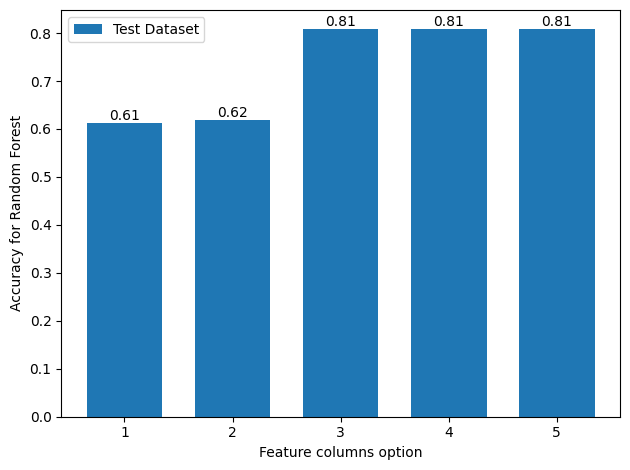

In [20]:
# Plot:
a=df_stats_test.collect()
accu_list_test_feat_var = a[0][:]

feat_set_feat_var = [1,2,3,4,5]

labels = ['1', '2', '3', '4', '5']

x = np.arange(len(labels))  # the label locations
width = 0.35*2              # the width of the bars

fig, ax = plt.subplots()
rects = ax.bar(x, accu_list_test_feat_var, width, label='Test Dataset')

# Add text for labels, title and custom x-axis tick labels.
ax.set_ylabel('Accuracy for Random Forest')
ax.set_xlabel("Feature columns option")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.bar_label(rects,labels= ['%.2f' % e for e in accu_list_test_feat_var])
ax.legend()

# Add a height-tag to the bars:
# DataVisualize.autolabel(rects)

fig.tight_layout()

filename = 'Feature_testonly_accu_bar'+suffix_s_w
path = os.path.join(LustrePrefix,local_classification_plot_dir, filename)
plt.savefig(path)

## Set to false since Spark IO might cause kernel crash.

In [21]:
if (False):
    # Write down the resulting DataFrame:
    print('writing down accuracy DataFrames...')
    path = os.path.join(LustrePrefix, local_data_dir,'df_test_accu_ds'+suffix_s_w+'.csv')
    df_test_accu.write.mode('overwrite').csv(path, header = True)